# 03 - Exploratory analysis

Target balance, feature correlations with default, and defaulted-vs-good behavior
comparisons. Figures are saved to `../outputs/figures/` for the final report.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme()
plt.rcParams.update({"axes.titlesize": 13, "axes.titleweight": "semibold"})
GOOD, DEFAULT = "#2e7cb6", "#d65f2c"

ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

f = pd.read_csv(DATA_DIR / "loan_features.csv")
print(f.shape)
print(f["target"].value_counts().rename({0: "good", 1: "default"}).to_string())

(682, 27)
target
good       606
default     76


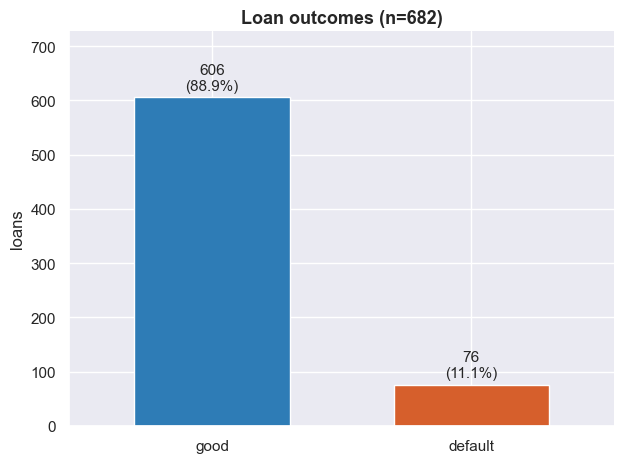

In [2]:
counts = f["target"].value_counts().rename({0: "good", 1: "default"}).reindex(["good", "default"])
ax = counts.plot.bar(color=[GOOD, DEFAULT], edgecolor="white", width=0.6)
ax.set_title("Loan outcomes (n=682)")
ax.set_ylabel("loans")
ax.set_xlabel("")
ax.set_xticklabels(["good", "default"], rotation=0)
ax.set_ylim(0, counts.max() * 1.2)
for bar, n in zip(ax.patches, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f"{n}\n({n / counts.sum():.1%})", ha="center", va="bottom", fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "target_dist.png", dpi=150, bbox_inches="tight")
plt.show()


min_balance       -0.261
balance_at_loan   -0.196
avg_balance       -0.160
n_withdrawal      -0.105
n_txn             -0.079
months_active     -0.075
txn_per_month     -0.067
sum_deposit       -0.057
sum_withdrawal    -0.041
n_deposit         -0.013
avg_amount        -0.007
age                0.012
max_balance        0.012
std_amount         0.019
gender_bin         0.021
duration           0.026
amount             0.168
payments           0.182


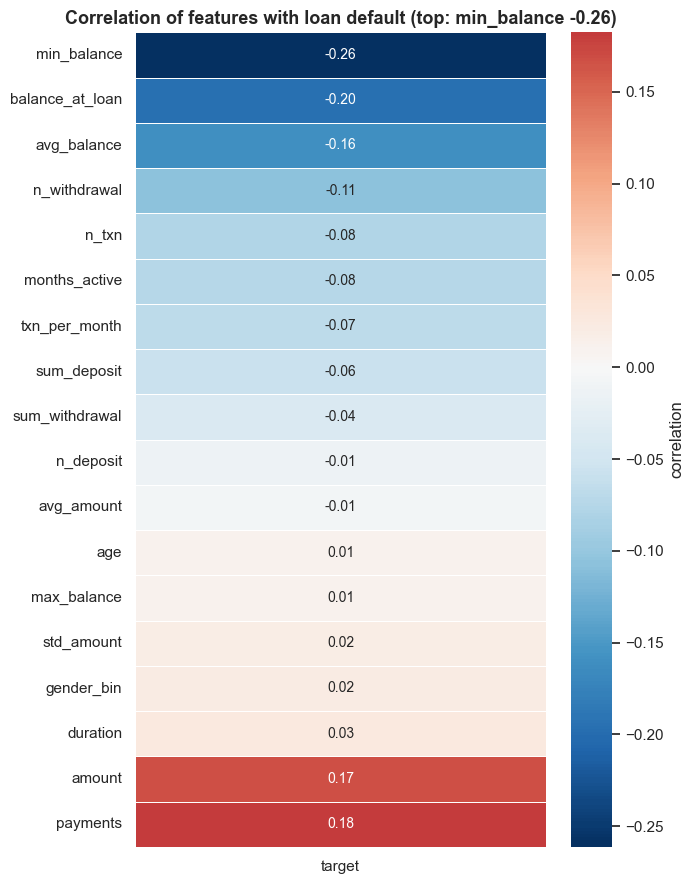

In [3]:
# "date" is a raw YYMMDD code, not a quantity, so it is excluded from every
# correlation table and from EDA (it is also dropped before modeling)
DROP_IDS = ["loan_id", "account_id", "client_id", "district_id", "date"]
num = f.select_dtypes("number").drop(columns=DROP_IDS)
corr = num.corr()["target"].drop("target").sort_values()
print(corr.round(3).to_string())

plt.figure(figsize=(7, 9))
sns.heatmap(corr.to_frame(), annot=True, fmt=".2f", annot_kws={"size": 10},
            cmap="RdBu_r", center=0, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "correlation"})
plt.title("Correlation of features with loan default (top: min_balance -0.26)")
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_target.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# Data quality: missing / duplicates / outliers-skew (Unit III evidence)
missing = f.isnull().sum()
missing = missing[missing > 0]
print("missing per col (top):")
print("none" if missing.empty else missing.to_string())
print("duplicated rows:", int(f.duplicated().sum()))
num_all = f.select_dtypes("number").drop(columns=DROP_IDS)
print(num_all.describe().round(1).T[["min", "mean", "max"]].to_string())
print("skew>1:", [c for c in num_all if float(num_all[c].skew()) > 1.0])

missing per col (top):
none
duplicated rows: 0
                     min      mean        max
amount            4980.0  151410.2   590820.0
duration            12.0      36.5       60.0
payments           304.0    4190.7     9910.0
target               0.0       0.1        1.0
n_txn                2.0      80.2      218.0
n_deposit            2.0      32.0       86.0
n_withdrawal         0.0      48.1      167.0
sum_deposit      10100.0  385871.8  1348329.3
sum_withdrawal       0.0  344055.4  1282370.0
avg_amount        1566.9    9488.7    26978.9
std_amount        1919.4   10916.7    23977.4
avg_balance       5350.0   43606.8    79500.5
min_balance     -17030.4     656.2    20574.0
max_balance      10100.0   89016.2   193909.9
balance_at_loan  -1571.5   42550.8   137843.0
months_active        3.4      13.1       22.9
txn_per_month        0.6       5.8       11.5
age                 19.0      40.9       64.0
gender_bin           0.0       0.5        1.0
skew>1: ['amount', 'target', 'sum

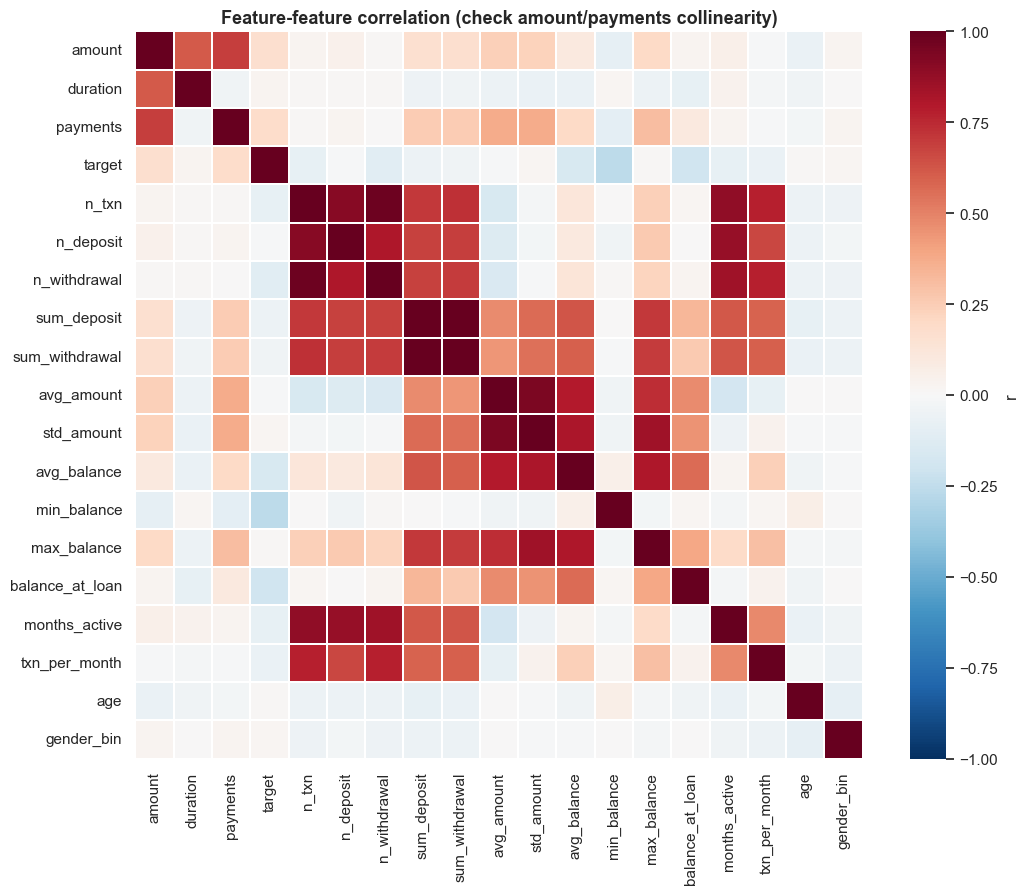

top |r| pairs (excl. diag):
sum_deposit   sum_withdrawal    0.997
n_txn         n_withdrawal      0.981
avg_amount    std_amount        0.941
n_txn         n_deposit         0.913
              months_active     0.894
n_deposit     months_active     0.871
n_withdrawal  months_active     0.850
std_amount    max_balance       0.847


In [5]:
# Full feature-feature correlation (multicollinearity check)
plt.figure(figsize=(11, 9))
sns.heatmap(num_all.corr().round(2), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor="white", cbar_kws={"label": "r"})
plt.title("Feature-feature correlation (check amount/payments collinearity)")
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("top |r| pairs (excl. diag):")
c = num_all.corr().abs()
import numpy as np
mask = np.triu(np.ones(c.shape), k=1).astype(bool)
print(c.where(mask).stack().sort_values(ascending=False).head(8).round(3).to_string())

gender:
          n  default_rate
gender                   
Female  348         0.118
Male    334         0.105

status:
          n  default_rate
status                   
A       203           0.0
B        31           1.0
C       403           0.0
D        45           1.0

balance_at_loan cut 38,550 | amount cut 116,928
                            n  default_rate
high balance low amount   163         0.049
             high amount  178         0.067
low balance  low amount   178         0.101
             high amount  163         0.233


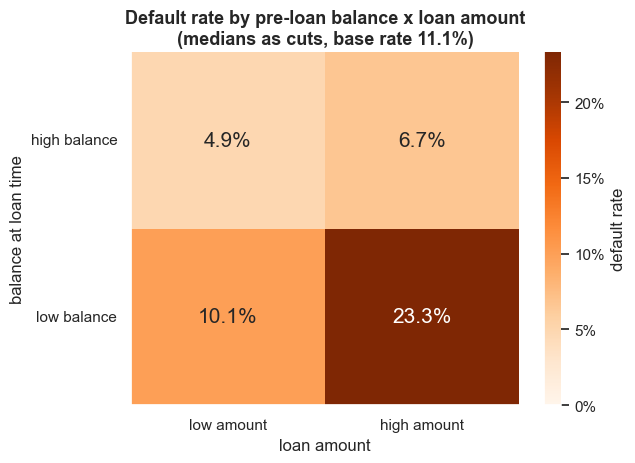

In [6]:
# Categorical EDA: gender / status vs default rate
for col in ["gender", "status"]:
    if col in f.columns:
        t = f.groupby(col)["target"].agg(n="size", default_rate="mean").round(3)
        print(col + ":")
        print(t.to_string())
        print()


# Risk quadrant: the two signals that matter, crossed at their medians
BAL_CUT, AMT_CUT = f["balance_at_loan"].median(), f["amount"].median()
f["balance_band"] = pd.Series(f["balance_at_loan"] < BAL_CUT, index=f.index).map(
    {True: "low balance", False: "high balance"})
f["amount_band"] = pd.Series(f["amount"] > AMT_CUT, index=f.index).map(
    {True: "high amount", False: "low amount"})
quad = (f.groupby(["balance_band", "amount_band"])["target"]
         .agg(n="size", default_rate="mean").round(3)
         .reindex(pd.MultiIndex.from_product(
             [["high balance", "low balance"], ["low amount", "high amount"]])))
print(f"balance_at_loan cut {BAL_CUT:,.0f} | amount cut {AMT_CUT:,.0f}")
print(quad.to_string())

q = quad["default_rate"].unstack()[["low amount", "high amount"]]
fig, ax = plt.subplots(figsize=(6.5, 4.8))
labels = [[f"{v:.1%}" for v in row] for row in q.values]
sns.heatmap(q * 100, annot=labels, fmt="", annot_kws={"size": 15}, cmap="Oranges",
            vmin=0, cbar_kws={"label": "default rate", "format": "%.0f%%"}, ax=ax)
ax.set_title("Default rate by pre-loan balance x loan amount\n(medians as cuts, base rate 11.1%)")
ax.set_xlabel("loan amount")
ax.set_ylabel("balance at loan time")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "risk_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()


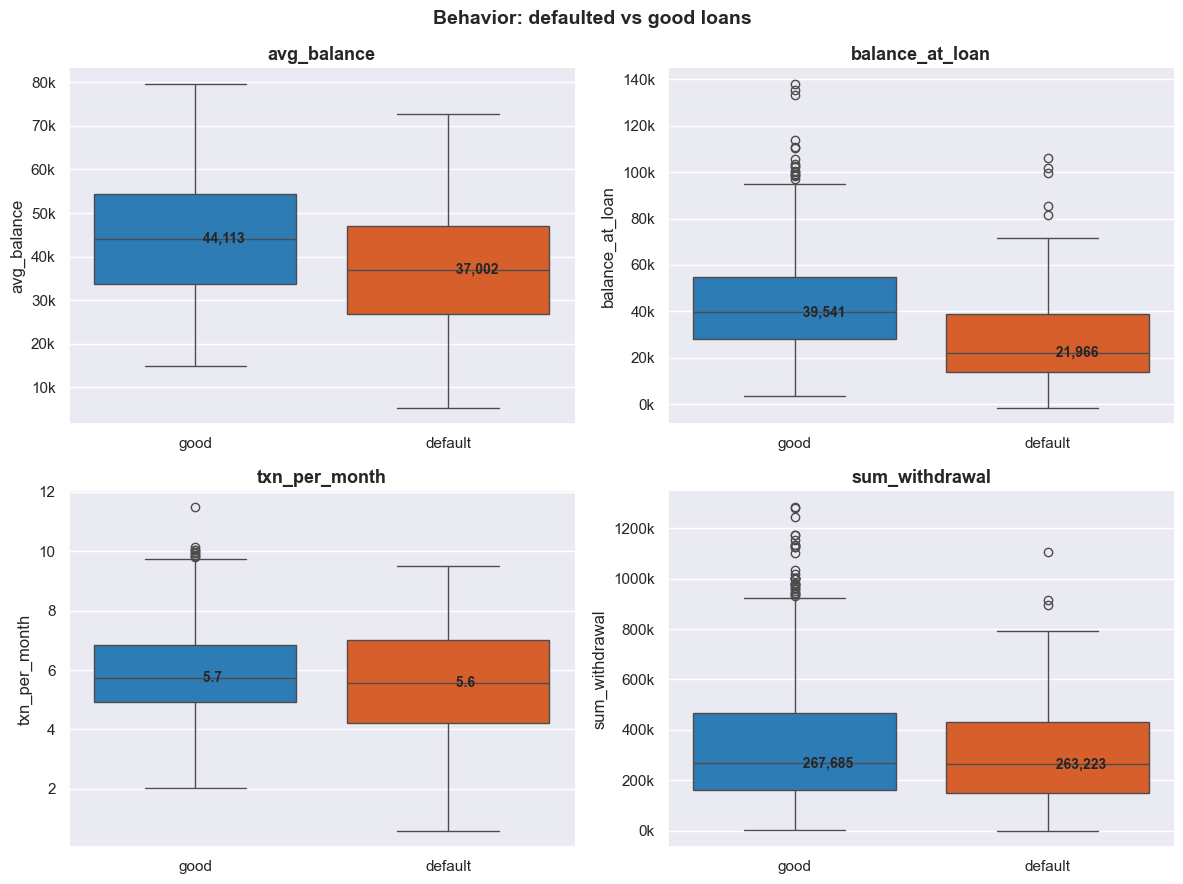

         avg_balance  balance_at_loan  txn_per_month  sum_withdrawal
target                                                              
good         44112.6          39541.0            5.7        267685.2
default      37001.6          21965.7            5.6        263223.3


In [7]:
cols = ["avg_balance", "balance_at_loan", "txn_per_month", "sum_withdrawal"]
k_format = {"avg_balance", "balance_at_loan", "sum_withdrawal"}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, cols):
    sns.boxplot(data=f, x="target", y=col, ax=ax)
    for box, color in zip(ax.patches, [GOOD, DEFAULT]):
        box.set_facecolor(color)
    ax.set_xticks([0, 1], ["good", "default"])
    ax.set_title(col)
    ax.set_xlabel("")
    for i, m in enumerate(f.groupby("target")[col].median()):
        label = f"  {m:.1f}" if col == "txn_per_month" else f"  {m:,.0f}"
        ax.text(i, m, label, va="center", fontsize=10, fontweight="semibold")
    if col in k_format:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
    sns.despine(ax=ax)
fig.suptitle("Behavior: defaulted vs good loans", fontsize=14, fontweight="semibold")
plt.tight_layout()
plt.savefig(FIG_DIR / "behavior_box.png", dpi=150, bbox_inches="tight")
plt.show()
print(f.groupby("target")[cols].median().round(1).rename({0: "good", 1: "default"}).to_string())


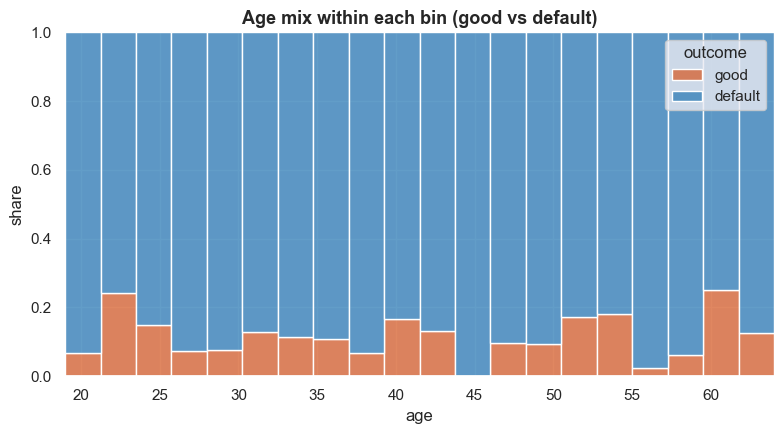

In [8]:
plt.figure(figsize=(8, 4.5))
ax = sns.histplot(data=f, x="age", hue="target", hue_order=[0, 1], bins=20,
                  palette=[GOOD, DEFAULT], multiple="fill", stat="proportion")
ax.set_title("Age mix within each bin (good vs default)")
ax.set_ylabel("share")
ax.legend(title="outcome", labels=["good", "default"])
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "age_hist.png", dpi=150, bbox_inches="tight")
plt.show()
